In [1]:
import requests
import pandas as pd 
from bs4 import BeautifulSoup as BS
import matplotlib.pyplot as plt
from urllib.parse import urljoin
import seaborn as sns
%matplotlib inline

In [2]:
url = url = "https://www.redbubble.com/shop/crying"
params = {"country": "IN", "deviceType": "desktop", "enableRedirects": "true", "locale": "en", "pageSize": 82, "ref": "search_box"}
headers = {"User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)" "AppleWebKit/537.36 (KHTML, like Gecko)" "Chrome/127.0.0.0 Safari/537.36")}

In [3]:
products_data = []
products = []

In [4]:
for page_no in range (1, 6):

    params["page"] = page_no
    print("Scrapping page:", page_no)
    reponse = requests.get(url, params = params ,headers = headers)

    print("Status    :",reponse.status_code)

    if (reponse.status_code != 200): 
        print("book not found")
        continue

    soup = BS(reponse.content, "html.parser")
    # with open(f"redbubble{page_no}.html", "w", encoding="utf-8") as f: f.write(soup.prettify())
    links = soup.find_all("a", href = True)

    products_per_page = []

    for link in links:
        href = link["href"]
        if "/i/" in href:
            product_url = urljoin("https://www.redbubble.com", href)
            if product_url not in products_per_page:
                products_per_page.append(link)

    products.extend(products_per_page)
    print("products found:", len(products))

Scrapping page: 1
Status    : 200
products found: 90
Scrapping page: 2
Status    : 200
products found: 180
Scrapping page: 3
Status    : 200
products found: 270
Scrapping page: 4
Status    : 200
products found: 360
Scrapping page: 5
Status    : 200
products found: 450


In [5]:
for product in products:

    name = product.find("span", class_=lambda x: x and "SearchResultCard_title__" in x)
    name = name.get_text(strip=True) if name else None

    author = None

    if name:
        title_block = product.find("span",class_=lambda x: x and "SearchResultCard_title__" in x).parent
        author_tag = title_block.find("div").find("span")
        if author_tag: author = author_tag.get_text(strip=True)

    
    price = product.find("span", attrs={"data-testid": "line-item-price-price"})
    price = price.get_text(strip=True) if price else None

    original = product.find("span", attrs={"data-testid": "line-item-undiscounted-price"})
    original = original.find("del").get_text(strip=True)
    products_data.append({"name": name, "author": author, "price": price, "original price": original})


In [6]:
df = pd.DataFrame(products_data)
df.head()

,name,author,price,original price
0,confused loading cat sticker Sticker,The Kiwi Store,$2.51,$2.78
1,Everything’s good cat Sticker,Ivanna Baca,$2.51,$2.78
2,Did The Thing Anyway Pink Sticker,Me And The Moon,$3.34,$3.71
3,Crying Dawson Sticker,aelmz,$2.72,$3.02
4,Sad Princess Cat Pin,drugues,$3.63,$4.54


In [7]:
df.to_csv("meme_products.csv",index=False,encoding="utf-8-sig")

In [8]:
df["price"] = df["price"].str.replace("$", "", regex=False).astype(float)
df["original price"] = df["original price"].str.replace("$", "", regex=False).astype(float)

In [9]:
df.head()

,name,author,price,original price
0,confused loading cat sticker Sticker,The Kiwi Store,2.51,2.78
1,Everything’s good cat Sticker,Ivanna Baca,2.51,2.78
2,Did The Thing Anyway Pink Sticker,Me And The Moon,3.34,3.71
3,Crying Dawson Sticker,aelmz,2.72,3.02
4,Sad Princess Cat Pin,drugues,3.63,4.54


In [10]:
df["discount %"] = ((df["original price"] - df["price"])/df["original price"])*100
df.head()

,name,author,price,original price,discount %
0,confused loading cat sticker Sticker,The Kiwi Store,2.51,2.78,9.712230
1,Everything’s good cat Sticker,Ivanna Baca,2.51,2.78,9.712230
2,Did The Thing Anyway Pink Sticker,Me And The Moon,3.34,3.71,9.973046
3,Crying Dawson Sticker,aelmz,2.72,3.02,9.933775
4,Sad Princess Cat Pin,drugues,3.63,4.54,20.044053


In [11]:
author_avg = df.groupby("author")[["original price", "discount %"]].mean().reset_index()

In [12]:
author_avg.head()

,author,original price,discount %
0,12jadis12,3.02,9.933775
1,2009fordfiesta,2.78,9.712230
2,989-,4.04,9.900990
3,ASamArt,25.06,30.007981
4,Adamarrington,56.03,14.991969


In [13]:
author_avg = author_avg.sort_values("original price", ascending=False).reset_index()
top = author_avg.head(5)
top

,index,author,original price,discount %
0,83,Jane Ianniello,97.49,20.002051
1,9,Alter-Idem,97.49,20.002051
2,335,swankyswamprat,80.36,40.007466
3,145,Sarah Teigland,79.85,9.993738
4,55,DungeonAtelier,69.75,29.992832


In [14]:
bottom = author_avg.tail(5)
bottom

,index,author,original price,discount %
350,170,Thurstonwaffles,2.44,10.245902
351,191,ameliaablossom,2.44,10.245902
352,209,bunnyfishing,2.44,10.245902
353,93,Larknado,2.44,10.245902
354,276,loveletter100,2.32,9.913793


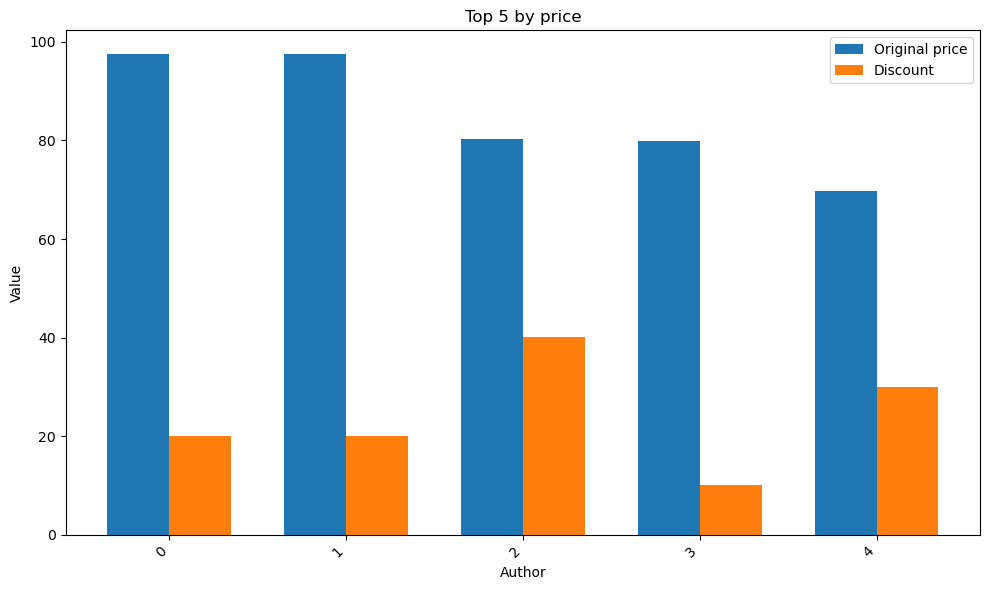

In [15]:
plt.figure(figsize=(10,6))

x = range(len(top))
width = 0.35

plt.bar([i - width/2 for i in x], top["original price"], width=width, label = "Original price")
plt.bar([i + width/2 for i in x], top["discount %"], width=width, label="Discount")

plt.xlabel("Author")
plt.ylabel("Value")
plt.title("Top 5 by price")

plt.xticks(x, top.index, rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

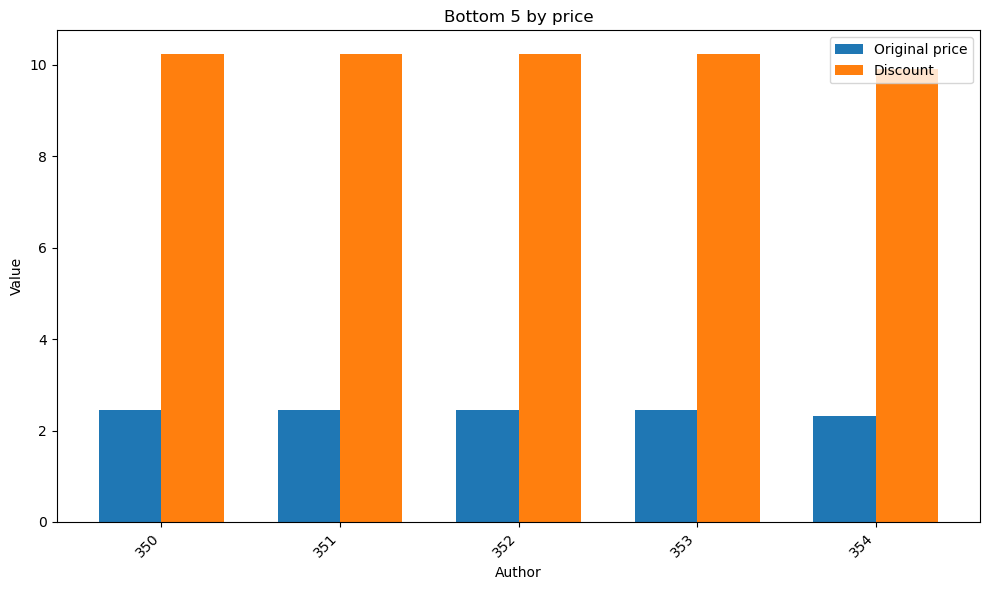

In [16]:
plt.figure(figsize=(10,6))

x = range(len(bottom))
width = 0.35

plt.bar([i - width/2 for i in x], bottom["original price"], width=width, label = "Original price")
plt.bar([i + width/2 for i in x], bottom["discount %"], width=width, label="Discount")

plt.xlabel("Author")
plt.ylabel("Value")
plt.title("Bottom 5 by price")

plt.xticks(x, bottom.index, rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()

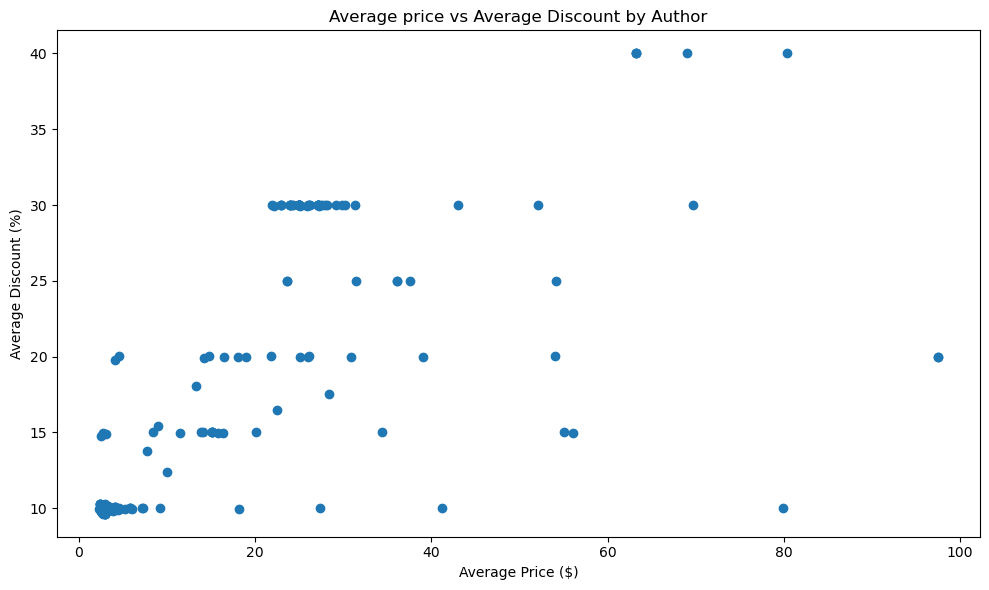

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(author_avg["original price"], author_avg["discount %"])

plt.xlabel("Average Price ($)")
plt.ylabel("Average Discount (%)")
plt.title("Average price vs Average Discount by Author")

plt.tight_layout()
plt.show()

In [18]:
correlation = author_avg['original price'].corr(author_avg['discount %'])
correlation

np.float64(0.753251925996282)

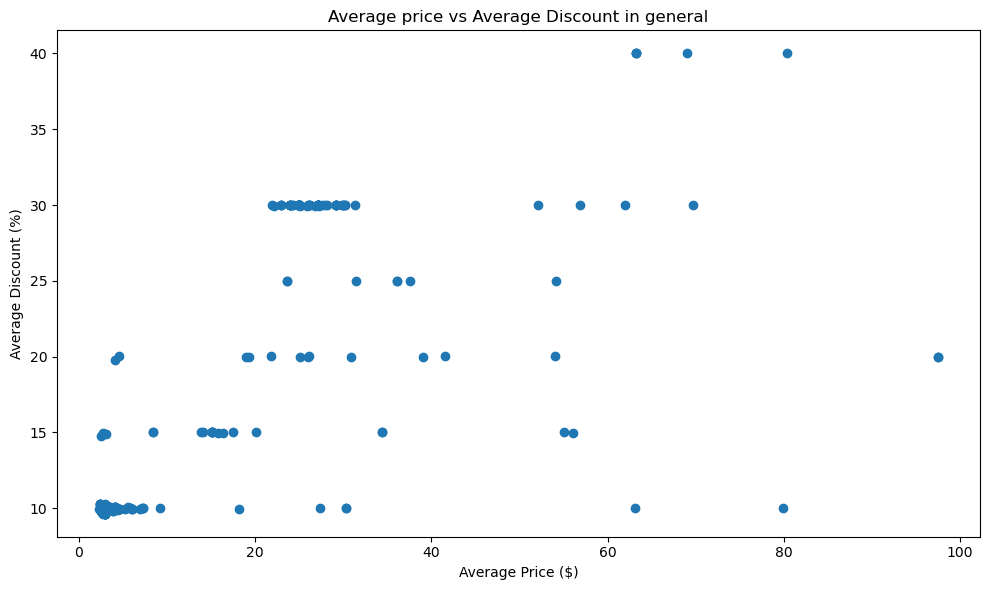

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(df["original price"], df["discount %"])

plt.xlabel("Average Price ($)")
plt.ylabel("Average Discount (%)")
plt.title("Average price vs Average Discount in general")

plt.tight_layout()
plt.show()

In [20]:
correlation = df['original price'].corr(df['discount %'])
correlation

np.float64(0.76019298423278)

In [21]:
df["original price"].skew()

np.float64(2.533007471396809)

In [22]:
df["discount %"].skew()

np.float64(1.4192139442418013)

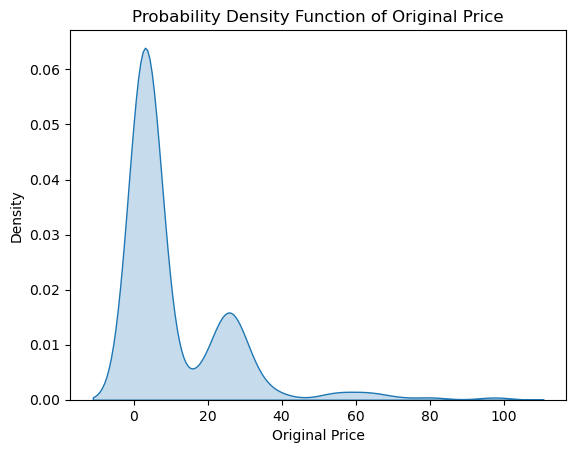

In [27]:
sns.kdeplot(df['original price'], fill=True)

plt.xlabel('Original Price')
plt.ylabel('Density')
plt.title('Probability Density Function of Original Price')
plt.show()

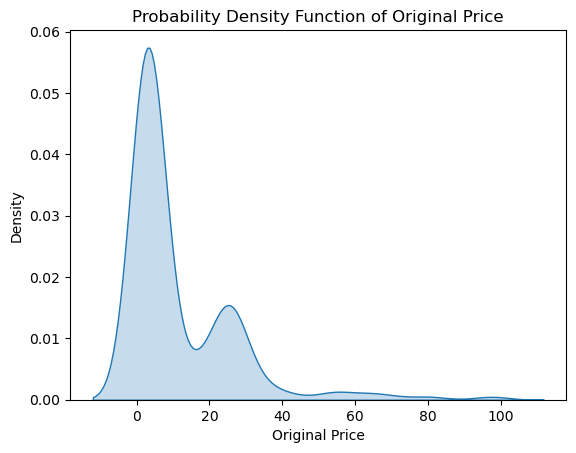

In [28]:
sns.kdeplot(author_avg['original price'], fill=True)

plt.xlabel('Original Price')
plt.ylabel('Density')
plt.title('Probability Density Function of Original Price')
plt.show()

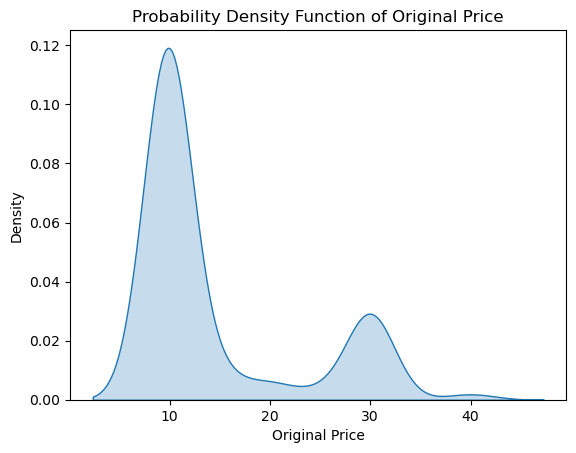

In [29]:
sns.kdeplot(df['discount %'], fill=True)

plt.xlabel('Original Price')
plt.ylabel('Density')
plt.title('Probability Density Function of Original Price')
plt.show()

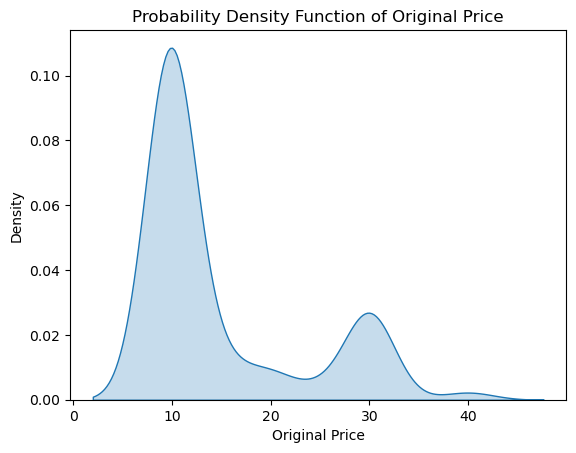

In [30]:
sns.kdeplot(author_avg['discount %'], fill=True)

plt.xlabel('Original Price')
plt.ylabel('Density')
plt.title('Probability Density Function of Original Price')
plt.show()

In [31]:
highest = df.loc[df['original price'].idxmax()]

print("Name:", highest['name'])
print("Author:", highest['author'])
print("Price:", highest['original price'])

Name: Pink Pop Art Crying Comic Girl Grief Canvas Print
Author: Jane Ianniello
Price: 97.49


In [32]:
highest = df.loc[df['discount %'].idxmax()]

print("Name:", highest['name'])
print("Author:", highest['author'])
print("discount:", highest['discount %'])

Name: STEM Student Meme Premium Oversized Hoodie
Author: swankyswamprat
discount: 40.00746640119463
